In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import warnings
warnings.simplefilter(action="ignore", category="SettingWithCopyWarning")

# Problem: Where could a used Ford F150 pickup truck with the optimum price-condition state be bought in the US?

## Profiling of used car auction data

In [2]:
cars = pd.read_csv("./car_prices.csv", on_bad_lines='skip')

In [3]:
cars.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [4]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 558811 entries, 0 to 558810
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558811 non-null  int64  
 1   make          548510 non-null  str    
 2   model         548412 non-null  str    
 3   trim          548160 non-null  str    
 4   body          545616 non-null  str    
 5   transmission  493458 non-null  str    
 6   vin           558811 non-null  str    
 7   state         558811 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558717 non-null  float64
 10  color         558062 non-null  str    
 11  interior      558062 non-null  str    
 12  seller        558811 non-null  str    
 13  mmr           558811 non-null  int64  
 14  sellingprice  558811 non-null  int64  
 15  saledate      558811 non-null  str    
dtypes: float64(2), int64(3), str(11)
memory usage: 132.8 MB


In [5]:
cars.describe()

,year,condition,odometer,mmr,sellingprice
count,558811.000000,547017.000000,558717.000000,558811.000000,558811.000000
mean,2010.038696,3.424512,68323.195797,13769.324646,13611.262461
std,3.966812,0.949439,53397.752933,9679.874607,9749.656919
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,2.700000,28374.000000,7100.000000,6900.000000
50%,2012.000000,3.600000,52256.000000,12250.000000,12100.000000
75%,2013.000000,4.200000,99112.000000,18300.000000,18200.000000
max,2015.000000,5.000000,999999.000000,182000.000000,230000.000000


In [6]:
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("darkgrid")

## Get the relationship matrix of numeric columns with a pairplot, on selected body types

In [7]:
cars_sampled = cars.sample(n=50000, random_state=42, replace=False, axis=0)

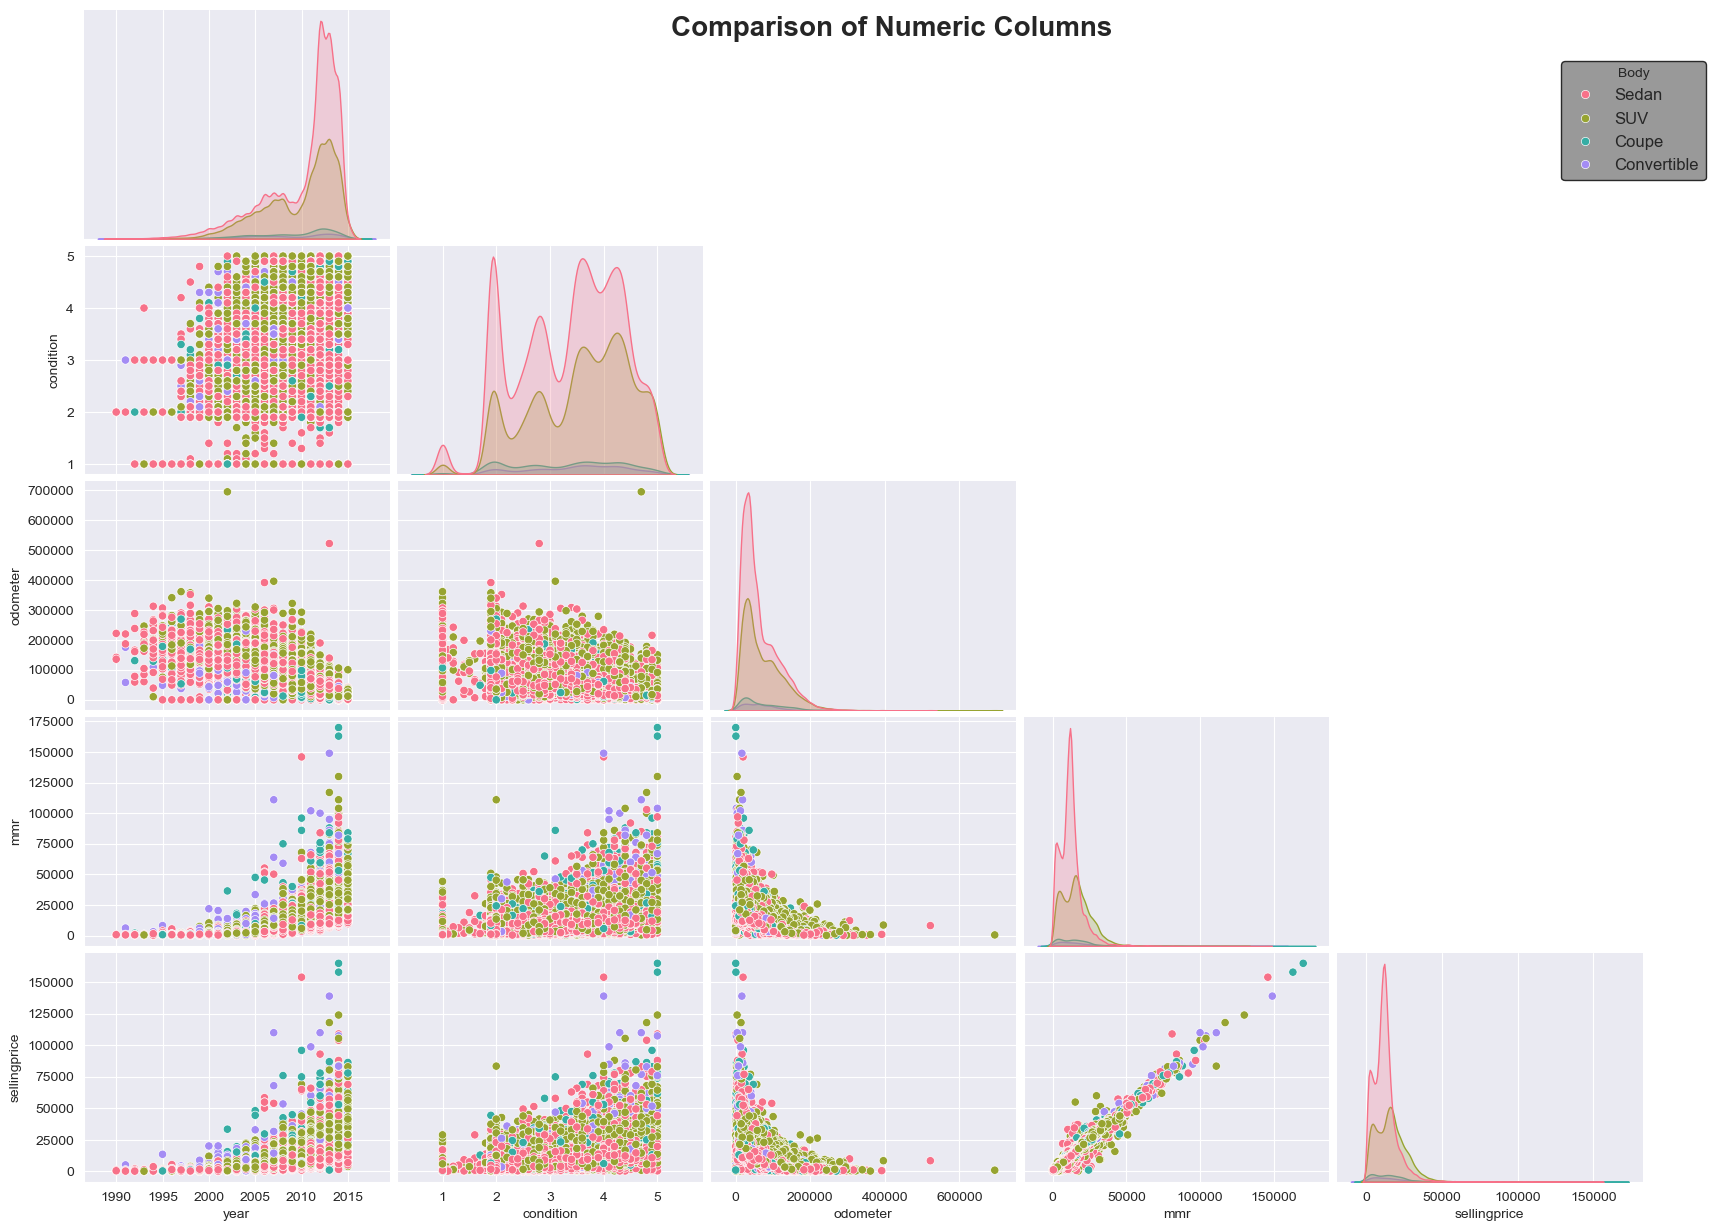

In [8]:
style_list = ["SUV", "Sedan", "Convertible", "Coupe"]
g = sns.pairplot(
	data=cars_sampled.loc[cars_sampled["body"].isin(style_list), :],
	hue="body",
	palette="husl",

	# kind="reg",
	# diag_kind="kde",

	aspect=1.25,
	
	dropna=True,
	corner=True,

	# plot_kws={"marker":"x"},
	diag_kws={"bw_adjust":0.8}
)
g.fig.suptitle("Comparison of Numeric Columns", fontsize=20, fontweight="bold")

g.legend.remove()
g.add_legend(loc='upper right',
			 bbox_to_anchor=(0.95, 0.95),
			 title="Body",
			 fontsize=12,
			 frameon=True,
			 facecolor="grey",
			 edgecolor="black");

### Findings
* When the year gets closer to the present day, the selling price and estimated price (mmr) increases.
* When condition of the car gets better, the selling price and estimated price (mmr) increases.
* When the distance covered by car (odometer) increases, the selling price and estimated price (mmr) decreases.
* The selling price and estimated price (mmr) are closely linked.

## Correlation heatmap between numeric variables

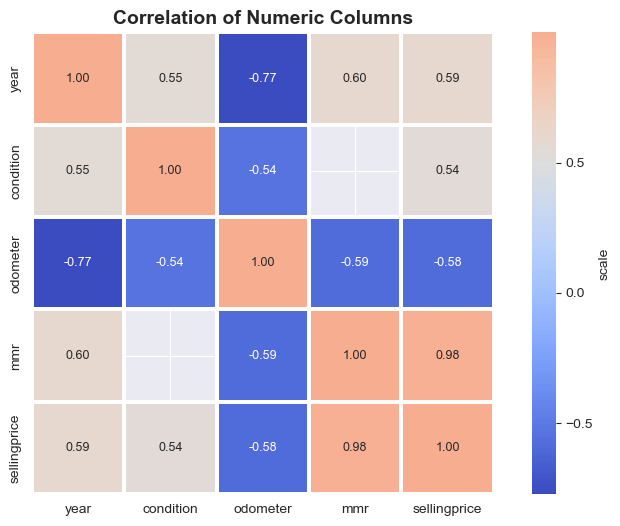

In [9]:
cars_corr = cars.corr(numeric_only=True)

sns.heatmap(
	data=cars_corr,
	mask=(cars_corr > -0.5) & (cars_corr < 0.5),
	
	center=0.5,
	square=True,

	annot=True,
	fmt=".2f",
	annot_kws={"family":"sans serif", "fontsize":9},

	cbar=True,
	cbar_kws={"label":"scale", "ticks":(-0.5, 0, 0.5), "fraction":0.1},

	lw=1.5,
	ec="0.5",

	cmap="coolwarm",
	shading="flat",

	snap=True,
	norm="linear"
)
plt.title("Correlation of Numeric Columns", fontsize=14, fontweight="bold");

### Findings (not clearly visible in the pairplot)
* Year and condition is somewhat positively correlated.
* Odometer values and condition are somewhat negatively correlated.
* Odometer values and year are highly negatively correlated.

## Let's see the negative correlation between odometer and selling price more clearly for selected makes

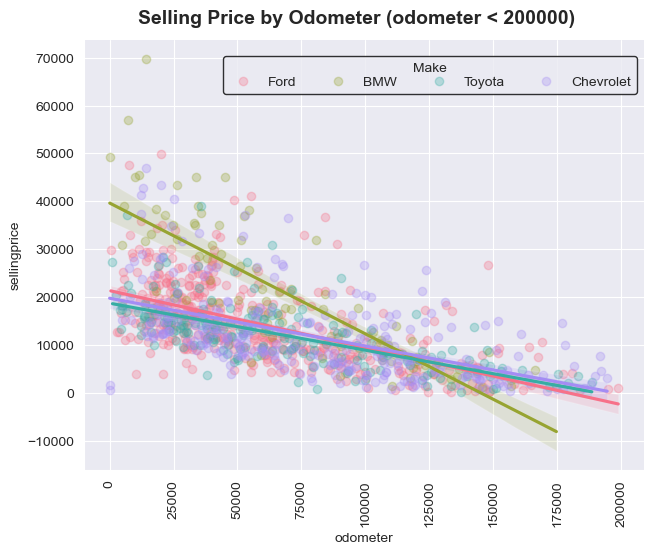

In [10]:
brand_list = ['Ford', 'BMW', 'Toyota', 'Chevrolet']
g = sns.lmplot(
	x="odometer",
	y="sellingprice",
	data=cars.query("make in @ brand_list and odometer < 200000").sample(n=1000, random_state=42, axis=0),
	hue="make",
	palette="husl",
	legend="full",

	# robust=True,
	truncate=True,
	y_jitter=True,
	x_estimator=None,
	# ci=95,
	scatter_kws={"alpha":0.3},
	
	aspect=1.25
)
plt.xticks(rotation=90)
g.fig.suptitle("Selling Price by Odometer (odometer < 200000)", fontsize=14, fontweight="bold", x=0.38, y=1.03)

g.legend.remove()
g.add_legend(loc='upper right',
			 bbox_to_anchor=(0.63, 0.95),
			 title="Make",
			 fontsize=10,
			 frameon=True,
			 # facecolor="0.9",
			 edgecolor="black",
			 ncol=4,
			 labelspacing=0.1
			);

### Findings
* BMW is the one that losts its value the most as odometer increases.
* The other three have nearly the same slope.

## Let's see the negative correlation between condition and selling price more clearly

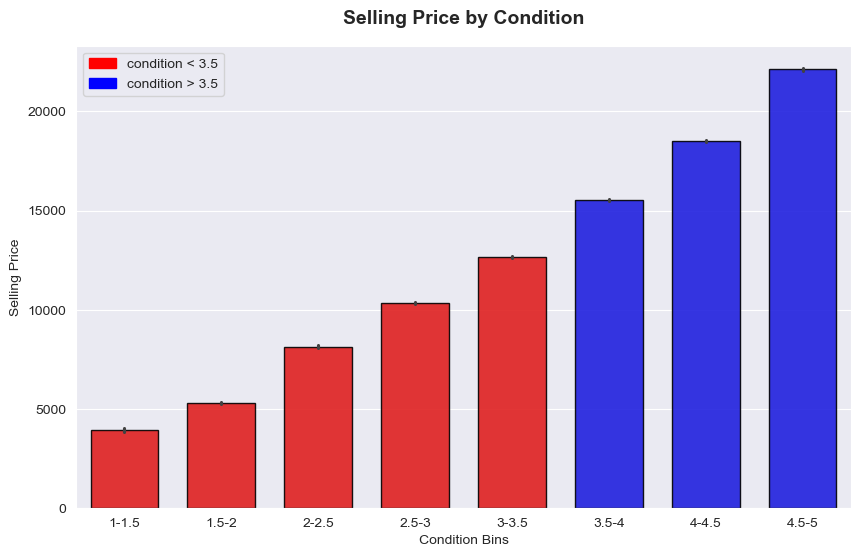

In [11]:
bins = np.linspace(1, 5, 9)
labels = ["1-1.5", "1.5-2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-4.5", "4.5-5"]

cars["condition_bins"] = pd.cut(x=cars["condition"], bins=bins, labels=labels, right=True, include_lowest=True)

sns.barplot(
	x="condition_bins",
	y="sellingprice",
	data=cars,
	hue="condition_bins",
	palette=["r","r","r","r","r","b","b","b"],
	# legend=False,

	estimator=np.mean,
	errorbar=('ci', 95),
	# capsize=0.025,

	gap=0.3,
	dodge=False,
	
	ec="0.0",
	lw=1,
	# color="b",

	width=1,
	alpha=0.9	
)
lows = patches.Patch(color="r", label="condition < 3.5")
highs = patches.Patch(color="b", label="condition > 3.5")
plt.legend(handles=[lows, highs])

plt.ylabel("Selling Price")
plt.xlabel("Condition Bins")
plt.title("Selling Price by Condition", fontsize=14, fontweight="bold", x=0.5, y=1.03);

### Findings
* Findings from the pairplot is confirmed.

## Let's see the relationship between condition and make: categorical variable relations

In [12]:
top_10_brands = cars["make"].value_counts().head(10).index

cars_pivot =(cars
	.pivot_table(index="make", columns="condition_bins", values="sellingprice", aggfunc="mean", observed=True)
	.loc[lambda x: x.index.isin(top_10_brands)]
			)
cars_pivot

condition_bins,1-1.5,1.5-2,2-2.5,2.5-3,3-3.5,3.5-4,4-4.5,4.5-5
make,,,,,,,,
BMW,4326.315789,6848.680865,10478.320029,12795.277669,16397.610281,21911.286118,28791.890310,35902.992693
Chevrolet,4500.217280,5384.030601,7425.967945,10325.668781,11622.675195,14436.514288,16733.687841,21580.124553
Chrysler,4591.439394,4301.224656,5367.031437,9077.602013,9247.621069,14813.315207,15212.500990,18388.446281
Dodge,4418.367347,5299.306603,7127.988641,9840.543230,10517.710952,14051.693213,14893.500000,18400.000000
Ford,3538.826389,5282.734146,8550.886379,10954.656807,13394.647490,15374.553012,17820.920366,20810.886556
Honda,2124.624060,5013.392857,7924.010577,9179.641598,11618.430007,13724.741442,16415.864917,19317.726330
Hyundai,6086.830144,5124.115218,7283.134792,8600.312323,10312.067568,11704.661821,13483.934264,16502.773497
Kia,4146.354167,4208.728571,6639.857005,8147.949483,10236.522039,11998.424662,13986.038947,16246.605411
Nissan,5144.738304,5509.596553,8431.096744,10016.940794,11893.454024,13056.597333,14654.276116,16105.622175


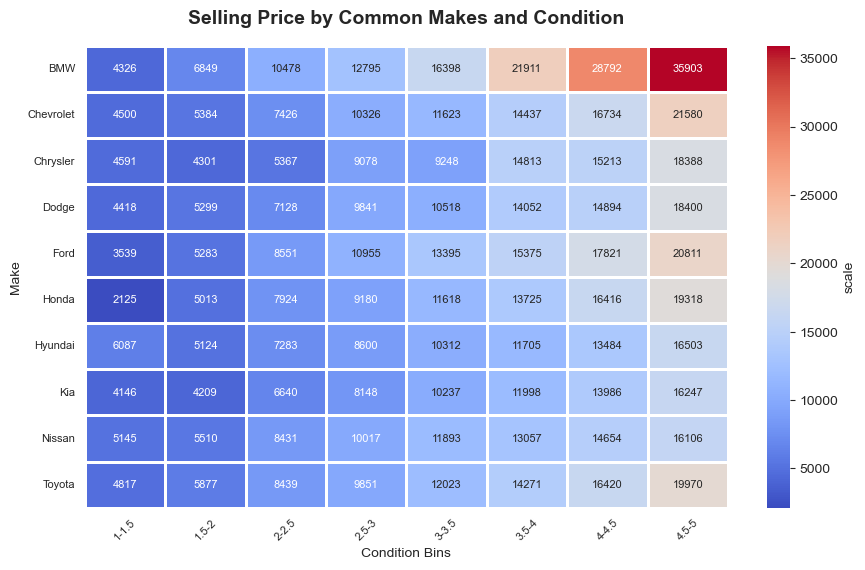

In [13]:
sns.heatmap(
	data=cars_pivot,
	square=False,

	annot=True,
	fmt=".0f",
	annot_kws={"fontsize":8},

	cbar=True,
	cbar_kws={"label":"scale", "fraction":0.12},

	
	lw=1,
	cmap="coolwarm",
	# shading="gouraud",
)
plt.xticks(rotation=45)
plt.tick_params(labelsize=8)
plt.ylabel("Make")
plt.xlabel("Condition Bins")
plt.title("Selling Price by Common Makes and Condition", fontsize=14, fontweight="bold", x=0.5, y=1.03);

### Findings
* Obviously Hyundai, Kia and Nissan models are possible to be bought for respectively cheaper prices and in better conditions.
* BMW models, as envisaged by lmplot above, are getting expensive as the condition gets better.
* Prices of all the other models range between 19 and 20 thousands for the best condition. Therefore, the Ford models could be bought for around 20000.

## Let's dive into the model F150s, first by finding distribution of their selling prices

In [14]:
f150s = cars[cars["model"] == "F-150"]
f150s.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,condition_bins
983,2012,Ford,F-150,XLT,SuperCrew,NaN,1ftew1cm9ckd05952,ca,4.6,51189.0,gray,gray,"ford motor credit company,llc pd",19700,20200,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),4.5-5
1013,2012,Ford,F-150,FX2,SuperCrew,automatic,1ftfw1ct0cfb64807,ca,4.6,28687.0,gray,black,"ford motor credit company,llc pd",26700,30500,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),4.5-5
1052,2012,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1et3ckd61619,ca,3.9,27465.0,black,gray,"ford motor credit company,llc pd",26300,28800,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),3.5-4
1054,2012,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1ef9cfc79834,ca,3.5,93858.0,white,gray,aaero sweet company,18900,19500,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),3-3.5
1074,2012,Ford,F-150,Lariat,SuperCab,automatic,1ftfx1ef6cfc80260,ca,4.1,46444.0,red,black,"ford motor credit company,llc pd",26300,25600,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),4-4.5


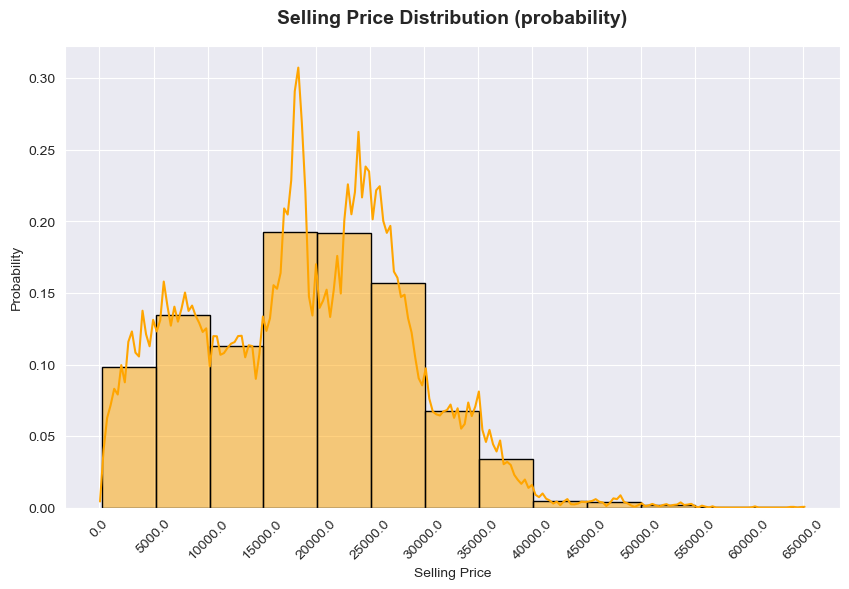

In [15]:
sns.histplot(
	x="sellingprice",
	data=f150s,
	
	kde=True,
	kde_kws={"bw_adjust":0.1, "cut":True},
	stat="probability",
	
	ec="black",
	color="orange",
	lw=1,

	binwidth=5000,
	alpha=0.5,
)
xticks = np.linspace(0, 65000, 14)
plt.xticks(ticks=xticks, labels=xticks, rotation=45)
plt.xlabel("Selling Price")
plt.title("Selling Price Distribution (probability)", fontsize=14, fontweight="bold", x=0.5, y=1.03);

### Findings
* 20% (majority) of the F150s sales are done at 20000 thousands. 

## Secondly, by comparing of their selling prices between their trims

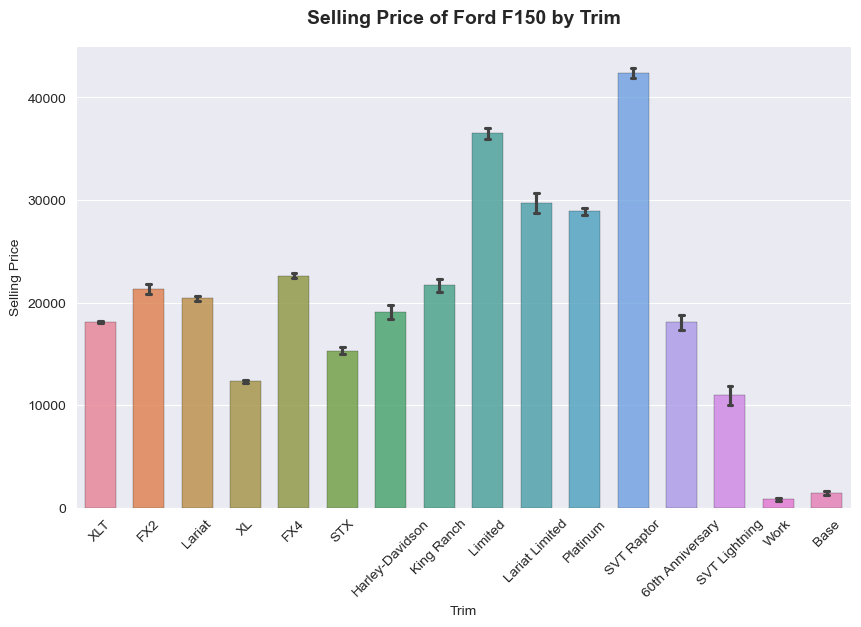

In [16]:
sns.barplot(
	x="trim",
	y="sellingprice",
	data=f150s,
	hue="trim",
	palette="husl",
	legend=False,

	gap=0.2,

	estimator=np.mean,
	errorbar="se",
	capsize=0.1,

	ec="0.0",
	lw=0.2,

	alpha=0.8
)
plt.xticks(rotation=45)
plt.ylabel("Selling Price")
plt.xlabel("Trim")
plt.title("Selling Price of Ford F150 by Trim", fontsize=14, fontweight="bold", x=0.5, y=1.03);

## Now, let's continue with conditon and selling price relationship, but specifically for the selected trims of f150s model this time

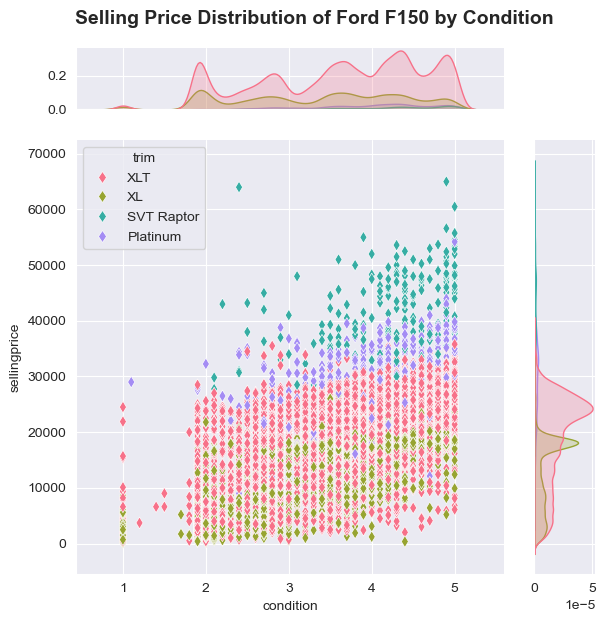

In [17]:
trim_list = ['XL', 'XLT', 'Platinum', 'SVT Raptor']
g = sns.jointplot(
	x="condition",
	y="sellingprice",
	data=f150s.query("trim in @trim_list"),
	hue="trim",
	palette="husl",
	legend="brief",

	kind="scatter",

	marginal_ticks=True,

	ratio=5,
	space=0.5,

	dropna=True,

	joint_kws={"marker":"d"},
	marginal_kws={"bw_adjust":0.5}
)
g.fig.suptitle("Selling Price Distribution of Ford F150 by Condition", fontsize=14, fontweight="bold", x=0.5, y=1.03);

### Findings
* XL and XLT trims are the cheapest trims for a respectively higher condition levels.

## Let's continue with the relationship between selling price - mmr difference (from now on, 'price difference') and color, to see which colors receive less amount than predicted or vice versa

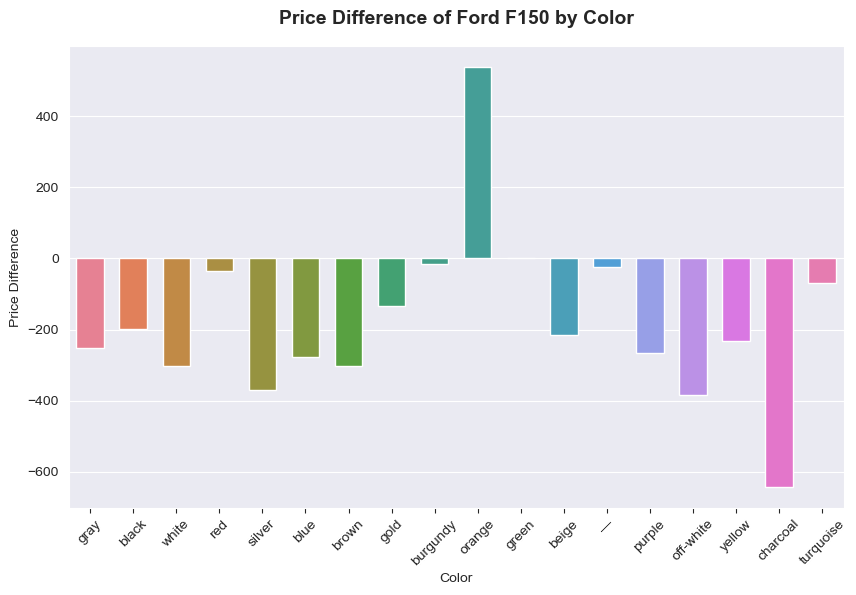

In [18]:
f150s.loc[:, "PriceDifference"] = f150s.loc[:, "sellingprice"] - f150s.loc[:, "mmr"]
sns.barplot(
	x="color",
	y="PriceDifference",
	data=f150s,
	hue="color",
	legend=False,

	gap=0.2,

	estimator=np.mean,
	errorbar=None,
)
plt.xticks(rotation=45)
plt.tick_params(bottom=True, direction="out")
plt.ylabel("Price Difference")
plt.xlabel("Color")
plt.title("Price Difference of Ford F150 by Color", fontsize=14, fontweight="bold", x=0.5, y=1.03);

### Findings
* charcoal, silver, and off-white colors are the colors that provide the most profit.
* Orange is the single color that renders buyer disadvantageous. 

## Let's focus on the selected trims that are not orange and the year of which are between 2009 and 2014

In [19]:
f150s_pivot = (f150s
	.query("trim in @trim_list and color != 'orange' and 2009 < year < 2014")
	.pivot_table(index="trim", columns="condition_bins", values="sellingprice", aggfunc="mean", observed=True))

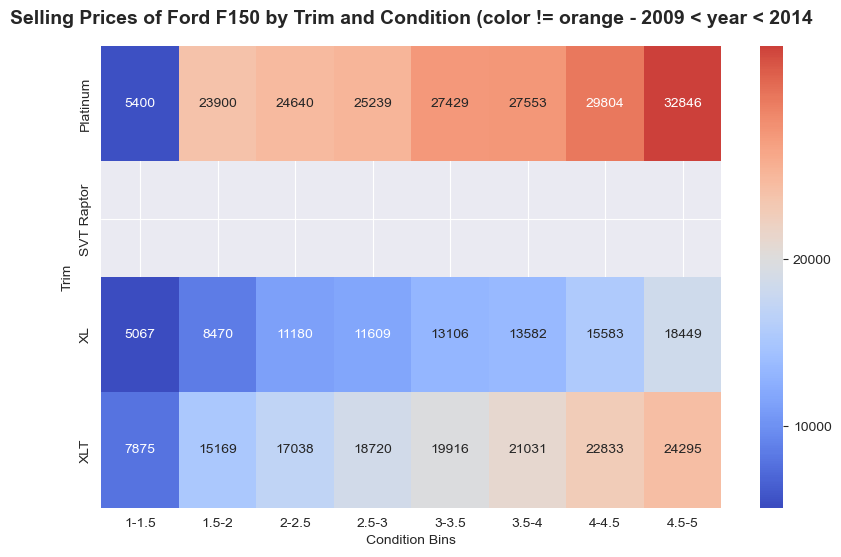

In [20]:
sns.heatmap(
	data=f150s_pivot,
	mask = f150s_pivot > 35000,
	
	square=False,
	center=20000,

	annot=True,
	fmt=".0f",
	cbar=True,
	cbar_kws={"ticks":(10000, 20000, 34000)},
	
	cmap="coolwarm",
	shading="flat",
)
plt.ylabel("Trim")
plt.xlabel("Condition Bins")
plt.title("Selling Prices of Ford F150 by Trim and Condition (color != orange - 2009 < year < 2014", fontsize=14, fontweight="bold", x=0.5, y=1.03);

### Findings
* XL is the most expensive trim of F150s.
* XLT is a middle-way trim.

## Finally, let's focus on the states to buy the trim XLT with a condition level of 3.5 and above, to see the price difference by state

In [21]:
f150s_reduced = (f150s
	.query("trim == 'XLT' and color != 'orange' and 2009 < year < 2014 and 3.5 <= condition")
	.sort_values(by="state")
	.assign(Count= lambda x:
			x.groupby("state")
				["state"].transform(lambda x: x.count()))
				)
f150s_reduced.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,condition_bins,PriceDifference,Count
32469,2013,Ford,F-150,XLT,SuperCrew,NaN,1ftfw1ef8dfb78513,ab,3.9,75112.0,brown,beige,cold lake ford,22200,22250,Thu Dec 18 2014 11:30:00 GMT-0800 (PST),3.5-4,50,50
51130,2013,Ford,F-150,XLT,SuperCrew,NaN,1ftfw1et9dfc21827,ab,3.9,22228.0,white,gray,"phh vehicle management services, inc",27900,23000,Thu Jan 08 2015 11:30:00 GMT-0800 (PST),3.5-4,-4900,50
52671,2012,Ford,F-150,XLT,SuperCrew,NaN,1ftfw1ef4cfb46866,ab,3.7,48990.0,white,gray,"phh vehicle management services, inc",23300,17250,Thu Jan 08 2015 11:30:00 GMT-0800 (PST),3.5-4,-6050,50
52694,2012,Ford,F-150,XLT,SuperCab,NaN,1ftfx1ef2cfb59094,ab,3.6,130856.0,blue,gray,"phh vehicle management services, inc",16450,13100,Thu Jan 08 2015 11:30:00 GMT-0800 (PST),3.5-4,-3350,50
52697,2012,Ford,F-150,XLT,SuperCrew,NaN,1ftfw1ef8cfc25683,ab,3.5,37156.0,white,gray,"phh vehicle management services, inc",24100,19500,Thu Jan 08 2015 11:30:00 GMT-0800 (PST),3-3.5,-4600,50


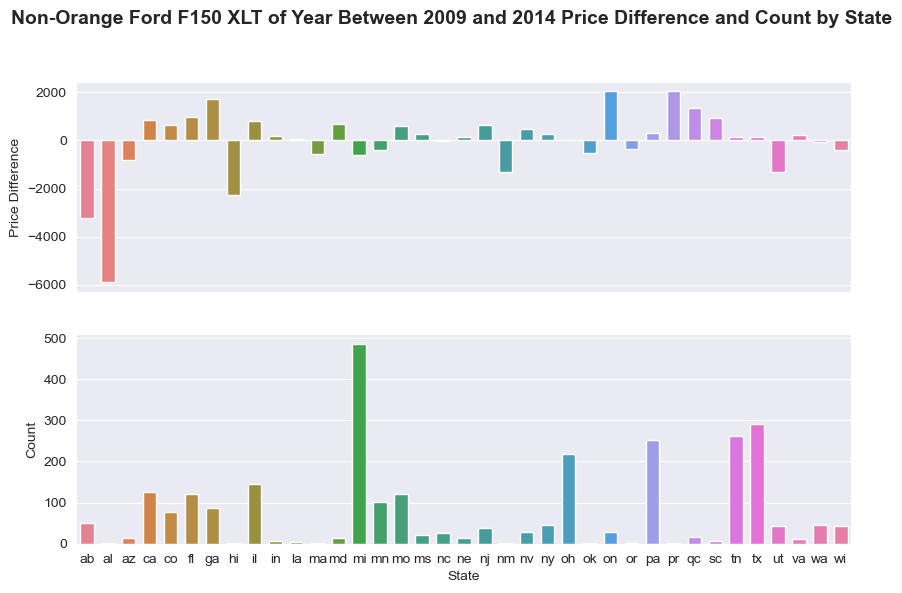

In [22]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
a1 = ax[0]
a2 = ax[1]

sns.barplot(
	x="state",
	y="PriceDifference",
	data=f150s_reduced,
	ax=a1,
	hue="state",
	legend=False,

	gap=0.2,

	estimator=np.mean,
	errorbar=None,	
)

sns.barplot(
	x="state",
	y="Count",
	data=f150s_reduced,
	ax=a2,
	hue="state",
	legend=False,

	gap=0.2,

	# estimator=np.mean,
	errorbar=None,	
)
a1.set_ylabel("Price Difference")
a2.set_xlabel("State")
fig.suptitle("Non-Orange Ford F150 XLT of Year Between 2009 and 2014 Price Difference and Count by State", fontsize=14, fontweight="bold", x=0.5, y=1);

### Findings
* Mission is to find the state where the price difference is considerably low and good amount of XLTs are sold.
* The states "ab" and "ut" conforms to the specification.